<a href="https://colab.research.google.com/github/Chekuriakhilvarma/Project_Code/blob/main/Project_Scratch_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Google Drive and define the training directory for the indoor scene dataset

from google.colab import drive

# Mount the user's Google Drive to make dataset files accessible
drive.mount('/content/drive')

# Abbreviated path variable for the indoor scene training dataset
ind_scene_tr_dir = '/content/drive/MyDrive/Dataset/train'
ind_scene_tst_dir = '/content/drive/MyDrive/Dataset/test'


Mounted at /content/drive


In [ ]:
# Install packages needed
!pip install -U keras-cv split-folders
# Import the libraries needed for this dissertation
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
# TensorFlow / Keras for model building
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, Input
from tensorflow.keras.models import Model
# InceptionV3 used as the CNN feature extraction branch
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
# Used for loading and augmenting the indoor scene image dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Training helpers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# Vision Transformer (ViT) model from KerasCV (legacy namespace)
import keras_cv
from keras_cv.src.models.legacy import ViTTiny16
# Metrics for evaluation and confusion matrix generation
from sklearn.metrics import (confusion_matrix,ConfusionMatrixDisplay,classification_report)
# Utility for splitting dataset folders into train/val/test sets
import splitfolders
# Reduce TensorFlow log noise and ignore warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 57.6 MB/s eta 0:00:00


In [ ]:
# Split the indoor scene dataset into training and validation folders
splitfolders.ratio(
    ind_scene_tr_dir,
    output="/content/IndoorScene_Split",
    seed=24000105,
    ratio=(0.70, 0.30),
    move=False
)

# Store the path to the training split directory
ind_scene_tr_split_dir = "/content/IndoorScene_Split/train"

# Store the path to the validation split directory
ind_scene_val_split_dir = "/content/IndoorScene_Split/val"

Copying files: 2227 files [05:37,  6.59 files/s]


In [ ]:
# Print dataset split directories and redefine core image configuration
print("Train dir:", ind_scene_tr_split_dir)
print("Val dir:", ind_scene_val_split_dir)
print("Test dir:", ind_scene_tst_dir)

# Define image resolution for CNN-based indoor scene models
img_sz = (299, 299)

# Define batch size used during training and evaluation
bt_sz = 32


Train dir: /content/IndoorScene_Split/train
Val dir: /content/IndoorScene_Split/val
Test dir: /content/drive/MyDrive/Dataset/test


In [ ]:
# Create data generators with augmentation for training and only preprocessing for validation and test
tr_data_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Create validation data generator without augmentation
val_data_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Create test data generator without augmentation
tst_data_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Load indoor scene training images from directory
tr_data_loader = tr_data_gen.flow_from_directory(
    ind_scene_tr_split_dir,
    target_size=img_sz,
    batch_size=bt_sz,
    class_mode="categorical",
    shuffle=True
)

# Load indoor scene validation images from directory
val_data_loader = val_data_gen.flow_from_directory(
    ind_scene_val_split_dir,
    target_size=img_sz,
    batch_size=bt_sz,
    class_mode="categorical",
    shuffle=False
)

# Load indoor scene test images from directory
tst_data_loader = tst_data_gen.flow_from_directory(
    ind_scene_tst_dir,
    target_size=img_sz,
    batch_size=bt_sz,
    class_mode="categorical",
    shuffle=False
)

# Store the number of indoor scene categories
scene_cls_cnt = tr_data_loader.num_classes

# Store the indoor scene class names
scene_cls_names = list(tr_data_loader.class_indices.keys())

# Print class labels and total class count
print("Classes:", scene_cls_names)
print("Num classes:", scene_cls_cnt)


Found 1553 images belonging to 15 classes.
Found 674 images belonging to 15 classes.
Found 601 images belonging to 15 classes.
Classes: ['auditorium', 'bowling', 'buffet', 'cloister', 'deli', 'florist', 'gym', 'laundromat', 'library', 'lobby', 'mall', 'museum', 'nursery', 'office', 'subway']
Num classes: 15


In [ ]:
# Define reusable building blocks for modern CNN architectures (DropPath, SE, MBConv)
@tf.keras.utils.register_keras_serializable()
class StochasticDepth(layers.Layer):
    """Randomly drops entire residual paths during training to improve generalization."""
    def __init__(self, sd_p=0.0, **kwargs):
        super().__init__(**kwargs)
        self.sd_p = float(sd_p)

    # Forward pass with optional stochastic depth during training
    def call(self, inputs, training=False):
        if (not training) or self.sd_p == 0.0:
            return inputs
        keep_rate = 1.0 - self.sd_p
        shape = (tf.shape(inputs)[0],) + (1,) * (len(inputs.shape) - 1)
        rand_tensor = keep_rate + tf.random.uniform(shape, 0, 1)
        bin_tensor = tf.floor(rand_tensor)
        return (inputs / keep_rate) * bin_tensor

    # Store configuration for model serialization
    def get_config(self):
        base_cfg = super().get_config()
        base_cfg.update({"sd_p": self.sd_p})
        return base_cfg


# Apply Squeeze-and-Excitation channel-wise attention
def squeeze_excite_block(feat_map, se_r=0.25, nm=None):
    """Recalibrate channel responses using global context."""
    ch_cnt = feat_map.shape[-1]
    red_ch = max(8, int(ch_cnt * se_r))
    se_vec = layers.GlobalAveragePooling2D(
        name=None if nm is None else f"{nm}_gap"
    )(feat_map)
    se_vec = layers.Dense(
        red_ch,
        activation="relu",
        name=None if nm is None else f"{nm}_fc1"
    )(se_vec)
    se_vec = layers.Dense(
        ch_cnt,
        activation="sigmoid",
        name=None if nm is None else f"{nm}_fc2"
    )(se_vec)
    se_vec = layers.Reshape(
        (1, 1, ch_cnt),
        name=None if nm is None else f"{nm}_reshape"
    )(se_vec)
    return layers.Multiply(
        name=None if nm is None else f"{nm}_scale"
    )([feat_map, se_vec])


# Define an MBConv block with expansion, depthwise conv, SE, and residual path
def mk_mbconv_blk(
    inputs,
    out_channels,
    exp_r=4,
    k_sz=3,
    st=1,
    se_r=0.25,
    sd_p=0.0,
    nm = None
):
    """Mobile inverted bottleneck convolution block with optional SE and DropPath."""
    in_channels = inputs.shape[-1]
    expanded_ch = int(in_channels * exp_r)
    skip_conn = inputs

    # Channel expansion phase
    if exp_r != 1:
        inputs = layers.Conv2D(
            expanded_ch,
            1,
            padding="same",
            use_bias=False,
            name=None if nm is None else f"{nm}_expand"
        )(inputs)
        inputs = layers.BatchNormalization(
            name=None if nm is None else f"{nm}_bn0"
        )(inputs)
        inputs = layers.Activation(
            "swish",
            name=None if nm is None else f"{nm}_act0"
        )(inputs)

    # Depthwise convolution for spatial filtering
    inputs = layers.DepthwiseConv2D(
        k_sz,
        strides=st,
        padding="same",
        use_bias=False,
        name=None if nm is None else f"{nm}_dw"
    )(inputs)
    inputs = layers.BatchNormalization(
        name=None if nm is None else f"{nm}_bn1"
    )(inputs)
    inputs = layers.Activation(
        "swish",
        name=None if nm is None else f"{nm}_act1"
    )(inputs)

    # Channel attention using squeeze-and-excitation
    if se_r and se_r > 0:
        inputs = squeeze_excite_block(
            inputs,
            se_r=se_r,
            nm=None if nm is None else f"{nm}_se"
        )

    # Projection back to output channels
    inputs = layers.Conv2D(
        out_channels,
        1,
        padding="same",
        use_bias=False,
        name=None if nm is None else f"{nm}_proj"
    )(inputs)
    inputs = layers.BatchNormalization(
        name=None if nm is None else f"{nm}_bn2"
    )(inputs)

    # Residual connection with optional stochastic depth
    if st == 1 and in_channels == out_channels:
        if sd_p > 0:
            inputs = StochasticDepth(
                sd_p=sd_p,
                name=None if nm is None else f"{nm}_droppath"
            )(inputs)
        inputs = layers.Add(
            name=None if nm is None else f"{nm}_add"
        )([skip_conn, inputs])

    return inputs


In [ ]:
# Build a strong-from-scratch MBConv+SE model for indoor scene classification
def build_scratch_mbconvse_model(
    in_shp=(299, 299, 3),
    cls_cnt=15,
    w_mul=1.0,
    dr_p=0.35,
    sd_max_p=0.10
):
    """Create an MBConv+SE CNN with stochastic depth tuned for indoor scene classification."""
    def sc_ch(base_ch):
        return max(16, int(base_ch * w_mul))

    inp = keras.Input(shape=in_shp, name="image")
    x = inp

    # Create the stem conv stack to downsample early and build low-level features
    x = layers.Conv2D(sc_ch(48), 3, strides=2, padding="same", use_bias=False, name="stem_conv1")(x)
    x = layers.BatchNormalization(name="stem_bn1")(x)
    x = layers.Activation("swish", name="stem_act1")(x)

    # Add a second stem conv to deepen early representations
    x = layers.Conv2D(sc_ch(64), 3, strides=1, padding="same", use_bias=False, name="stem_conv2")(x)
    x = layers.BatchNormalization(name="stem_bn2")(x)
    x = layers.Activation("swish", name="stem_act2")(x)

    # Create a linear stochastic-depth schedule across all MBConv blocks
    blk_cnt = 16
    sd_sched = [sd_max_p * (i / max(1, blk_cnt - 1)) for i in range(blk_cnt)]
    blk_i = 0

    # Build stage 1 blocks at the same resolution
    x = mk_mbconv_blk(x, sc_ch(64),  exp_r=2, k_sz=3, st=1, se_r=0.25, sd_p=sd_sched[blk_i], nm=f"s1_b{blk_i}"); blk_i += 1
    x = mk_mbconv_blk(x, sc_ch(64),  exp_r=2, k_sz=3, st=1, se_r=0.25, sd_p=sd_sched[blk_i], nm=f"s1_b{blk_i}"); blk_i += 1

    # Build stage 2 with a downsampling block followed by refinement blocks
    x = mk_mbconv_blk(x, sc_ch(96),  exp_r=4, k_sz=3, st=2, se_r=0.25, sd_p=sd_sched[blk_i], nm=f"s2_b{blk_i}"); blk_i += 1
    x = mk_mbconv_blk(x, sc_ch(96),  exp_r=4, k_sz=3, st=1, se_r=0.25, sd_p=sd_sched[blk_i], nm=f"s2_b{blk_i}"); blk_i += 1
    x = mk_mbconv_blk(x, sc_ch(96),  exp_r=4, k_sz=3, st=1, se_r=0.25, sd_p=sd_sched[blk_i], nm=f"s2_b{blk_i}"); blk_i += 1

    # Build stage 3 with larger kernels for broader context
    x = mk_mbconv_blk(x, sc_ch(144), exp_r=4, k_sz=5, st=2, se_r=0.25, sd_p=sd_sched[blk_i], nm=f"s3_b{blk_i}"); blk_i += 1
    x = mk_mbconv_blk(x, sc_ch(144), exp_r=4, k_sz=5, st=1, se_r=0.25, sd_p=sd_sched[blk_i], nm=f"s3_b{blk_i}"); blk_i += 1
    x = mk_mbconv_blk(x, sc_ch(144), exp_r=4, k_sz=5, st=1, se_r=0.25, sd_p=sd_sched[blk_i], nm=f"s3_b{blk_i}"); blk_i += 1

    # Build stage 4 as the main capacity stage with multiple blocks
    x = mk_mbconv_blk(x, sc_ch(208), exp_r=6, k_sz=5, st=2, se_r=0.25, sd_p=sd_sched[blk_i], nm=f"s4_b{blk_i}"); blk_i += 1
    x = mk_mbconv_blk(x, sc_ch(208), exp_r=6, k_sz=5, st=1, se_r=0.25, sd_p=sd_sched[blk_i], nm=f"s4_b{blk_i}"); blk_i += 1
    x = mk_mbconv_blk(x, sc_ch(208), exp_r=6, k_sz=5, st=1, se_r=0.25, sd_p=sd_sched[blk_i], nm=f"s4_b{blk_i}"); blk_i += 1
    x = mk_mbconv_blk(x, sc_ch(208), exp_r=6, k_sz=5, st=1, se_r=0.25, sd_p=sd_sched[blk_i], nm=f"s4_b{blk_i}"); blk_i += 1

    # Build stage 5 to refine features before the head
    x = mk_mbconv_blk(x, sc_ch(288), exp_r=6, k_sz=3, st=1, se_r=0.25, sd_p=sd_sched[blk_i], nm=f"s5_b{blk_i}"); blk_i += 1
    x = mk_mbconv_blk(x, sc_ch(288), exp_r=6, k_sz=3, st=1, se_r=0.25, sd_p=sd_sched[blk_i], nm=f"s5_b{blk_i}"); blk_i += 1
    x = mk_mbconv_blk(x, sc_ch(288), exp_r=6, k_sz=3, st=1, se_r=0.25, sd_p=sd_sched[blk_i], nm=f"s5_b{blk_i}"); blk_i += 1

    # Build the head conv to expand capacity before global pooling
    x = layers.Conv2D(sc_ch(512), 1, padding="same", use_bias=False, name="head_conv")(x)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Activation("swish", name="head_act")(x)

    # Pool spatial dims and apply dropout for regularization
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(dr_p, name="head_drop")(x)

    # Add a dense layer for final feature mixing before classification
    x = layers.Dense(sc_ch(512), activation="swish", name="head_fc1")(x)
    x = layers.Dropout(dr_p * 0.6, name="head_drop2")(x)

    # Output probabilities in float32 for numerical stability
    out = layers.Dense(cls_cnt, activation="softmax", dtype="float32", name="pred")(x)

    return keras.Model(inp, out, name="ScratchIndoor_MBConvSE")


# Instantiate the scratch model using the shared image size and dataset class count
scr_mdl = build_scratch_mbconvse_model(
    in_shp=(img_sz[0], img_sz[1], 3),
    cls_cnt=scene_cls_cnt,
    w_mul=1.0,
    dr_p=0.35,
    sd_max_p=0.10
)

# Print the scratch model architecture summary
scr_mdl.summary(line_length=150)


Model: "ScratchIndoor_MBConvSE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━
┃ Layer (type)                               ┃ Output Shape                         ┃                 Param # ┃ Con
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━
│ image (InputLayer)                         │ (None, 299, 299, 3)                  │                       0 │ -  
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ stem_conv1 (Conv2D)                        │ (None, 150, 150, 48)                 │                   1,296 │ ima
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ stem_bn1 (BatchNormalization)              │ (None, 150, 150, 48)                 │                     192 │ ste
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ stem_act1 (Activation)                     │ (None, 150, 150, 48)                 │                       0 │ ste
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ stem_conv2 (Conv2D)                        │ (None, 150, 150, 64)                 │                  27,648 │ ste
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ stem_bn2 (BatchNormalization)              │ (None, 150, 150, 64)                 │                     256 │ ste
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ stem_act2 (Activation)                     │ (None, 150, 150, 64)                 │                       0 │ ste
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ s1_b0_expand (Conv2D)                      │ (None, 150, 150, 128)                │                   8,192 │ ste
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ s1_b0_bn0 (BatchNormalization)             │ (None, 150, 150, 128)                │                     512 │ s1_
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ s1_b0_act0 (Activation)                    │ (None, 150, 150, 128)                │                       0 │ s1_
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ s1_b0_dw (DepthwiseConv2D)                 │ (None, 150, 150, 128)                │                   1,152 │ s1_
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ s1_b0_bn1 (BatchNormalization)             │ (None, 150, 150, 128)                │                     512 │ s1_
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ s1_b0_act1 (Activation)                    │ (None, 150, 150, 128)                │                       0 │ s1_
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ s1_b0_se_gap (GlobalAveragePooling2D)      │ (None, 128)                          │                       0 │ s1_
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ s1_b0_se_fc1 (Dense)                       │ (None, 32)                           │                   4,128 │ s1_
├────────────────────────────────────────────┼──────────────────────────────────────┼─────────────────────────┼────
│ s1_b0_se_fc2 (Dense)                       │ (None, 128)                          │                   4,224 │ s1_
├────────────────────────────────────────────┼──────────

 Total params: 12,971,831 (49.48 MB)

 Trainable params: 12,916,983 (49.27 MB)

 Non-trainable params: 54,848 (214.25 KB)

In [ ]:
# Configure optimizer, learning-rate schedule, and compile the scratch indoor scene model
steps_per_ep = len(tr_data_loader)

# Define total number of training epochs
num_epochs = 60

# Create a cosine decay learning rate schedule for stable convergence
cos_lr_sched = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-4,
    decay_steps=steps_per_ep * num_epochs,
    alpha=1e-2
)

# Initialize AdamW optimizer with weight decay regularization
adamw_opt = tf.keras.optimizers.AdamW(
    learning_rate=cos_lr_sched,
    weight_decay=2e-4
)

# Define categorical cross-entropy loss with label smoothing
ce_loss = tf.keras.losses.CategoricalCrossentropy(
    label_smoothing=0.1
)

# Compile the scratch-built indoor scene model
scr_mdl.compile(
    optimizer=adamw_opt,
    loss=ce_loss,
    metrics=["accuracy"]
)


In [ ]:
# Train the scratch-built indoor scene model with early stopping and checkpointing
scr_es_cb = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

# Save the best-performing scratch model based on validation accuracy
scr_ckpt_cb = ModelCheckpoint(
    "best_scratch_indoor_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Fit the scratch model on the indoor scene training data
scr_tr_hist = scr_mdl.fit(
    tr_data_loader,
    validation_data=val_data_loader,
    epochs=num_epochs,
    callbacks=[scr_es_cb, scr_ckpt_cb],
    verbose=1
)

Epoch 1/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1880 - loss: 2.5718
Epoch 1: val_accuracy improved from -inf to 0.21958, saving model to best_scratch_indoor_model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 334s 4s/step - accuracy: 0.1888 - loss: 2.5700 - val_accuracy: 0.2196 - val_loss: 2.6782
Epoch 2/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2743 - loss: 2.3237
Epoch 2: val_accuracy did not improve from 0.21958
49/49 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.2746 - loss: 2.3235 - val_accuracy: 0.2196 - val_loss: 2.6498
Epoch 3/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3087 - loss: 2.2551
Epoch 3: val_accuracy did not improve from 0.21958
49/49 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.3090 - loss: 2.2542 - val_accuracy: 0.2196 - val_loss: 2.6305
Epoch 4/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3347 - loss: 2.1662
Epoch 4: val_accuracy did not improve from 0.21958
49/49 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.3345 - loss: 2.

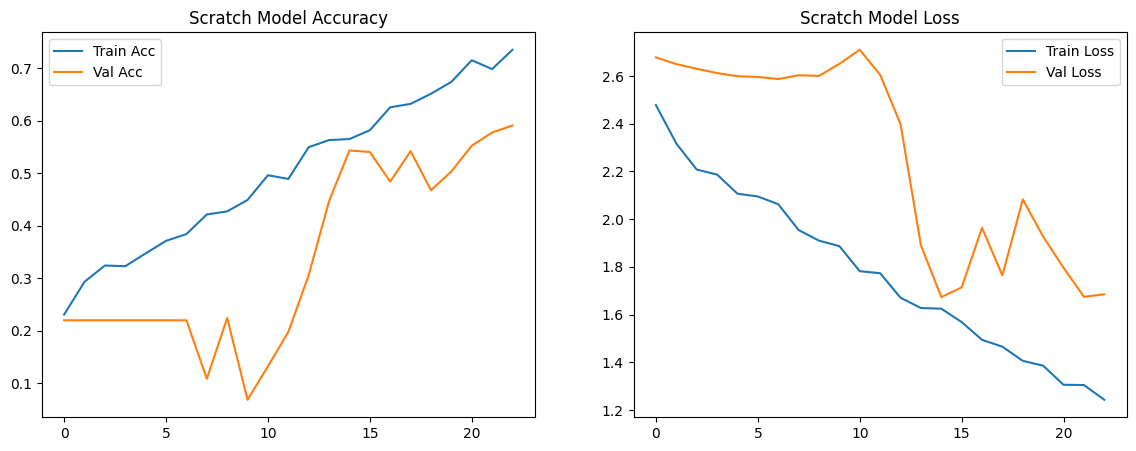

In [ ]:
# Plot training and validation accuracy and loss curves for the scratch-built indoor scene model
plt.figure(figsize=(14, 5))

# Plot accuracy trends over epochs
plt.subplot(1, 2, 1)
plt.plot(scr_tr_hist.history["accuracy"], label="Train Acc")
plt.plot(scr_tr_hist.history["val_accuracy"], label="Val Acc")
plt.title("Scratch Model Accuracy")
plt.legend()

# Plot loss trends over epochs
plt.subplot(1, 2, 2)
plt.plot(scr_tr_hist.history["loss"], label="Train Loss")
plt.plot(scr_tr_hist.history["val_loss"], label="Val Loss")
plt.title("Scratch Model Loss")
plt.legend()

# Display the plots
plt.show()


In [ ]:
# Set up cosine-decay learning rate, AdamW optimizer, and label-smoothed loss for scratch model training
steps_ep = len(tr_data_loader)

# Define total epochs used to compute cosine decay steps
ep_cnt = 60

# Create a cosine decay schedule for the learning rate
lr_sched = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-4,
    decay_steps=steps_ep * ep_cnt,
    alpha=1e-2
)

# Configure AdamW with the scheduled learning rate and weight decay
opt_admw = tf.keras.optimizers.AdamW(
    learning_rate=lr_sched,
    weight_decay=2e-4
)

# Use categorical cross-entropy with label smoothing for better generalization
loss_cce_ls = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

# Compile the scratch model with the optimizer, loss, and accuracy metric
scr_mdl.compile(
    optimizer=opt_admw,
    loss=loss_cce_ls,
    metrics=["accuracy"]
)


22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 569ms/step


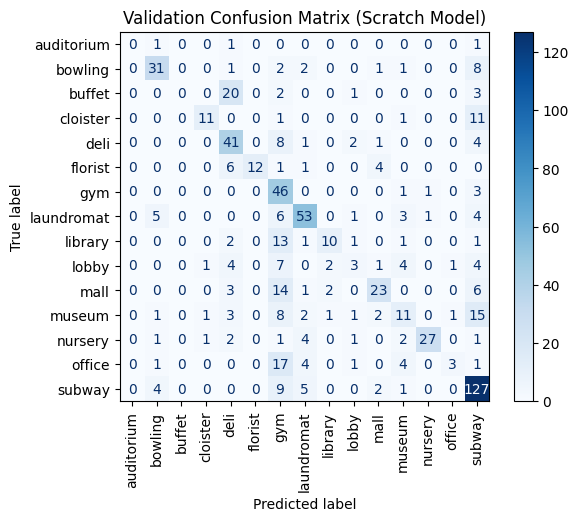

Validation Classification Report (Scratch Model):

              precision    recall  f1-score   support

  auditorium       0.00      0.00      0.00         3
     bowling       0.70      0.67      0.69        46
      buffet       0.00      0.00      0.00        26
    cloister       0.79      0.46      0.58        24
        deli       0.49      0.72      0.59        57
     florist       1.00      0.50      0.67        24
         gym       0.34      0.90      0.49        51
  laundromat       0.72      0.73      0.72        73
     library       0.67      0.34      0.45        29
       lobby       0.27      0.11      0.16        27
        mall       0.68      0.47      0.55        49
      museum       0.38      0.24      0.29        46
     nursery       0.93      0.68      0.78        40
      office       0.60      0.10      0.17        31
      subway       0.67      0.86      0.75       148

    accuracy                           0.59       674
   macro avg       0.55      

In [ ]:
# Load the best-performing scratch indoor scene model from disk
scr_best_mdl = tf.keras.models.load_model(
    "best_scratch_indoor_model.keras",
    compile=False
)

# Compile the loaded scratch model for evaluation
scr_best_mdl.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Reset validation loader before running inference
val_data_loader.reset()

# Generate prediction probabilities on the validation set
val_prob_scr = scr_best_mdl.predict(val_data_loader, verbose=1)

# Convert probabilities into predicted class indices
val_pred_scr = np.argmax(val_prob_scr, axis=1)

# Extract ground-truth validation labels
val_true_scr = val_data_loader.classes

# Compute confusion matrix for scratch model validation results
cm_scr_val = confusion_matrix(val_true_scr, val_pred_scr)

# Display the confusion matrix with indoor scene class labels
cm_disp_scr = ConfusionMatrixDisplay(
    confusion_matrix=cm_scr_val,
    display_labels=scene_cls_names
)

# Plot the validation confusion matrix
cm_disp_scr.plot(xticks_rotation="vertical", cmap="Blues")
plt.title("Validation Confusion Matrix (Scratch Model)")
plt.show()

# Print the detailed classification report for validation data
print("Validation Classification Report (Scratch Model):\n")
print(classification_report(val_true_scr, val_pred_scr, target_names=scene_cls_names))


In [ ]:
# Print final training and validation accuracy for the scratch indoor scene model
tr_acc = scr_tr_hist.history["accuracy"][-1]

# Extract the final validation accuracy value
val_acc = scr_tr_hist.history["val_accuracy"][-1]

# Display the accuracy values
print(f"Scratch Model Training Accuracy: {tr_acc:.4f}")
print(f"Scratch Model Validation Accuracy: {val_acc:.4f}")


Scratch Model Training Accuracy: 0.7347
Scratch Model Validation Accuracy: 0.5905


19/19 ━━━━━━━━━━━━━━━━━━━━ 450s 24s/step - accuracy: 0.2209 - loss: 3.3827
Scratch Test Accuracy: 0.4226289391517639
Scratch Test Loss: 2.28757905960083
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 616ms/step


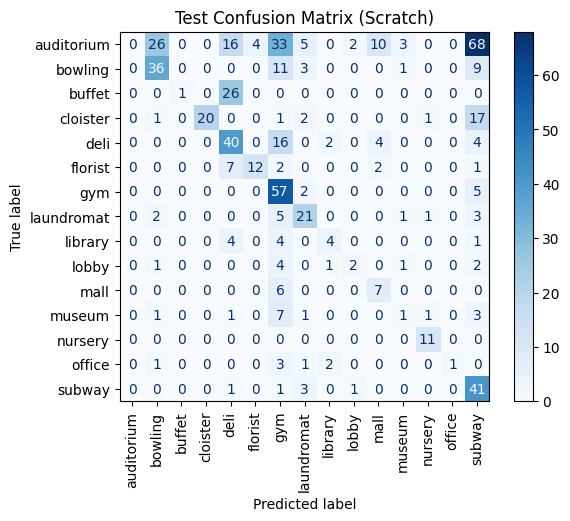

Test Classification Report (Scratch):

              precision    recall  f1-score   support

  auditorium       0.00      0.00      0.00       167
     bowling       0.53      0.60      0.56        60
      buffet       1.00      0.04      0.07        27
    cloister       1.00      0.48      0.65        42
        deli       0.42      0.61      0.50        66
     florist       0.75      0.50      0.60        24
         gym       0.38      0.89      0.53        64
  laundromat       0.55      0.64      0.59        33
     library       0.44      0.31      0.36        13
       lobby       0.40      0.18      0.25        11
        mall       0.30      0.54      0.39        13
      museum       0.14      0.07      0.09        15
     nursery       0.79      1.00      0.88        11
      office       1.00      0.12      0.22         8
      subway       0.27      0.87      0.41        47

    accuracy                           0.42       601
   macro avg       0.53      0.46      0.

In [ ]:
# Evaluate the best scratch model on the indoor scene test set and report metrics
best_scratch_mdl = tf.keras.models.load_model("best_scratch_indoor_model.keras", compile=False)

# Compile the loaded scratch model to enable evaluation metrics
best_scratch_mdl.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Run evaluation on the test loader
tst_loss_scr, tst_acc_scr = best_scratch_mdl.evaluate(
    tst_data_loader,
    verbose=1
)

# Print test performance numbers
print("Scratch Test Accuracy:", tst_acc_scr)
print("Scratch Test Loss:", tst_loss_scr)

# Reset the test loader before generating predictions
tst_data_loader.reset()

# Predict class probabilities for all test images
tst_probs_scr = best_scratch_mdl.predict(
    tst_data_loader,
    verbose=1
)

# Convert probabilities into predicted class indices
tst_pred_scr = np.argmax(tst_probs_scr, axis=1)

# Extract true class indices from the test loader
tst_true_scr = tst_data_loader.classes

# Compute confusion matrix on the test set
tst_cm_scr = confusion_matrix(
    tst_true_scr,
    tst_pred_scr
)

# Visualize the confusion matrix using class names
tst_disp_scr = ConfusionMatrixDisplay(
    confusion_matrix=tst_cm_scr,
    display_labels=scene_cls_names
)

# Plot the confusion matrix with rotated tick labels
tst_disp_scr.plot(
    xticks_rotation="vertical",
    cmap="Blues"
)

# Add a title to the plot for context
plt.title("Test Confusion Matrix (Scratch)")

# Render the plot
plt.show()

# Print the detailed classification report for the test set
print("Test Classification Report (Scratch):\n")
print(classification_report(tst_true_scr, tst_pred_scr, target_names=scene_cls_names))


In [ ]:
# Utilities for locating convolution layers and generating Grad-CAM visualizations for CNN-based indoor models

def get_last_conv_name(mdl):
    """
    Identify the name of the last convolutional layer suitable for Grad-CAM.

    Searches first for Conv2D layers with 4D outputs, then falls back to
    DepthwiseConv2D layers if needed.
    """
    for lyr in reversed(mdl.layers):
        if isinstance(lyr, tf.keras.layers.Conv2D):
            try:
                shp = lyr.output_shape
                if len(shp) == 4:
                    return lyr.name
            except Exception:
                pass

    for lyr in reversed(mdl.layers):
        if isinstance(lyr, tf.keras.layers.DepthwiseConv2D):
            return lyr.name

    raise ValueError("No valid convolutional layer found for Grad-CAM.")


def prep_img_for_cam(img_pth):
    """
    Load an image and prepare both display and model-ready tensors
    using the same preprocessing as the indoor CNN models.
    """
    pil_img = keras.preprocessing.image.load_img(
        img_pth,
        target_size=img_sz
    )

    img_arr = keras.preprocessing.image.img_to_array(pil_img)

    disp_arr = img_arr / 255.0

    mdl_arr = preprocess_input(img_arr.copy())

    mdl_arr = np.expand_dims(mdl_arr, axis=0)

    return pil_img, disp_arr, mdl_arr


def gen_gradcam_map(inp_tensor, mdl, conv_name=None):
    """
    Generate a Grad-CAM heatmap for a given input tensor and model.

    Automatically finds the last convolutional layer if not provided.
    """
    if conv_name is None:
        conv_name = get_last_conv_name(mdl)

    conv_lyr = mdl.get_layer(conv_name)

    cam_mdl = tf.keras.models.Model(
        [mdl.inputs],
        [conv_lyr.output, mdl.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = cam_mdl(inp_tensor)
        cls_idx = tf.argmax(preds[0])
        cls_score = preds[:, cls_idx]

    grads = tape.gradient(cls_score, conv_out)

    avg_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]

    cam = tf.reduce_sum(conv_out * avg_grads, axis=-1)

    cam = tf.nn.relu(cam)

    cam = cam / (tf.reduce_max(cam) + 1e-8)

    return cam.numpy(), int(cls_idx.numpy()), conv_name


def blend_cam_on_img(disp_img, cam_map, alpha=0.4):
    """
    Overlay a Grad-CAM heatmap onto a display-ready RGB image.
    """
    img_u8 = (disp_img * 255).astype("uint8")

    cam_rs = cv2.resize(
        cam_map,
        (img_u8.shape[1], img_u8.shape[0])
    )

    cam_clr = cv2.applyColorMap(
        np.uint8(255 * cam_rs),
        cv2.COLORMAP_JET
    )

    mix = cv2.addWeighted(
        img_u8,
        1 - alpha,
        cam_clr,
        alpha,
        0
    )

    mix = cv2.cvtColor(mix, cv2.COLOR_BGR2RGB)

    return mix


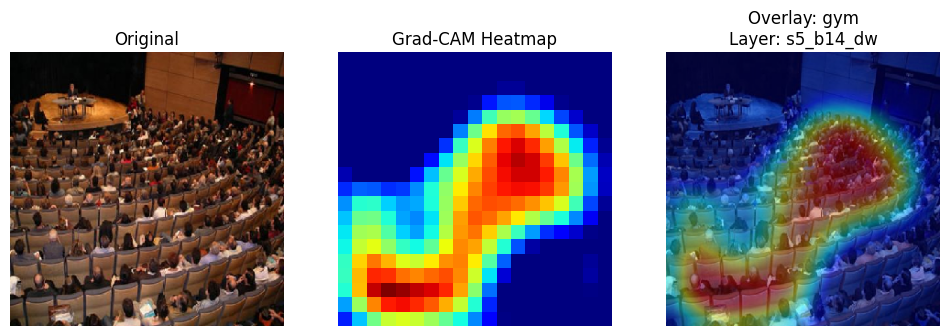

In [40]:
# Run Grad-CAM on one test image using the scratch model and display original, heatmap, and overlay
img_idx = 98

# Select an image path from the test loader
img_pth = tst_data_loader.filepaths[img_idx]

# Load and preprocess the image for Grad-CAM
orig_img, disp_img, cam_inp = prep_img_for_cam(img_pth)

# Generate Grad-CAM heatmap and predicted class index
hm, pred_idx, cam_lyr_nm = gen_gradcam_map(cam_inp, best_scratch_mdl, conv_name=None)

# Convert predicted index to class name
pred_cls_nm = scene_cls_names[pred_idx]

# Create an overlay visualization
ovl_img = blend_cam_on_img(disp_img, hm, alpha=0.4)

# Create a figure for visualization
plt.figure(figsize=(12, 4))

# Show the original image
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(orig_img)
plt.axis("off")

# Show the raw heatmap
plt.subplot(1, 3, 2)
plt.title("Grad-CAM Heatmap")
plt.imshow(hm, cmap="jet")
plt.axis("off")

# Show the overlay with predicted class and chosen layer
plt.subplot(1, 3, 3)
plt.title(f"Overlay: {pred_cls_nm}\nLayer: {cam_lyr_nm}")
plt.imshow(ovl_img)
plt.axis("off")

# Render the visualizations
plt.show()


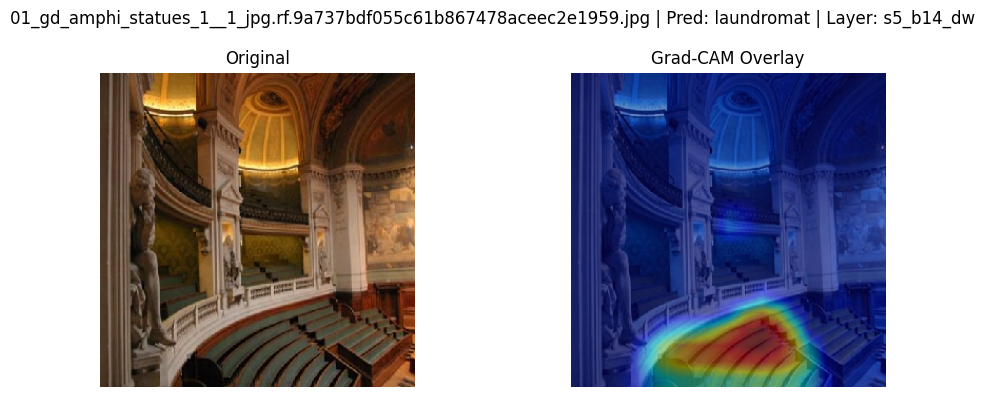

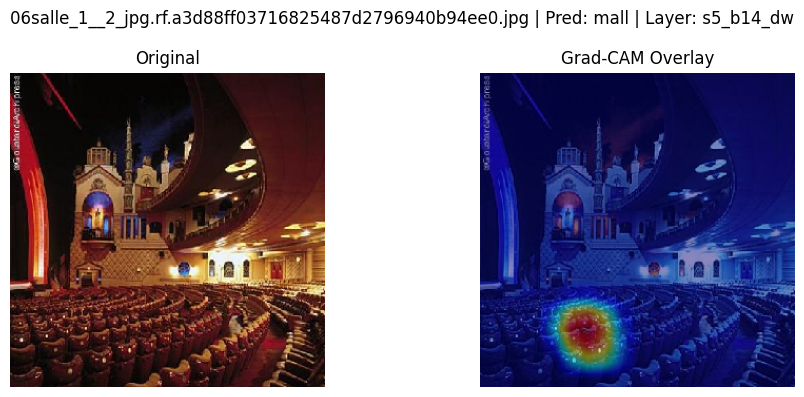

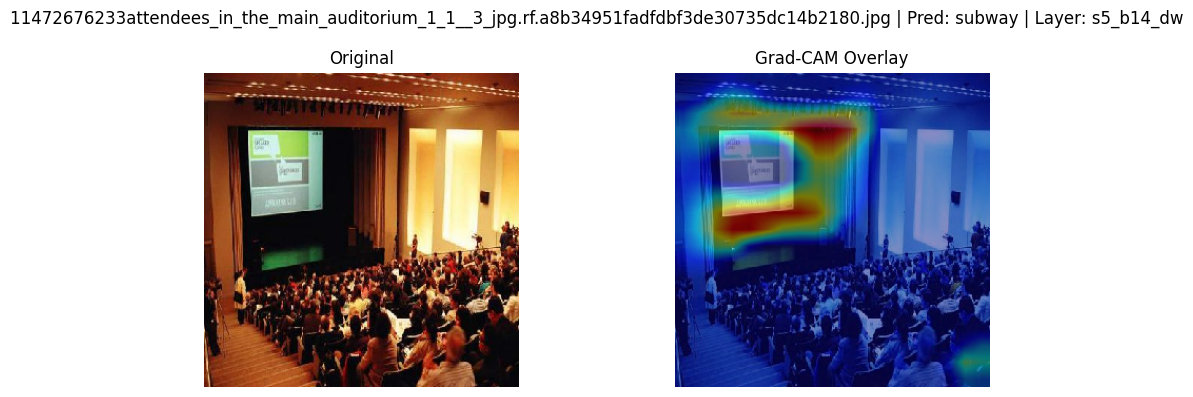

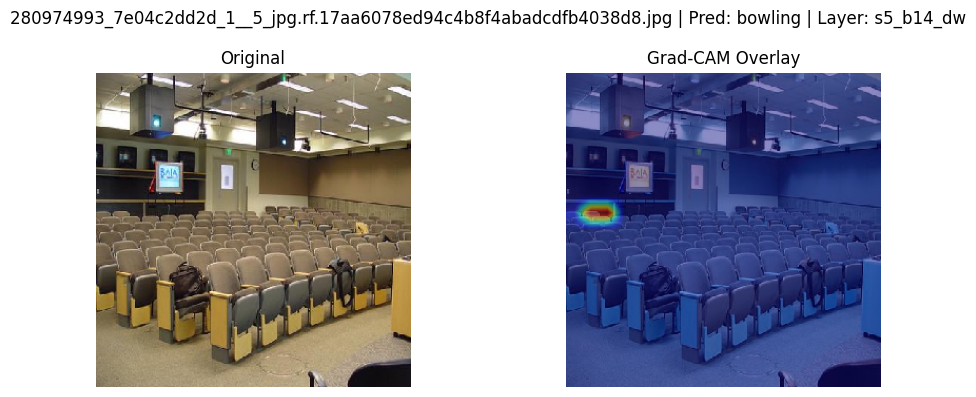

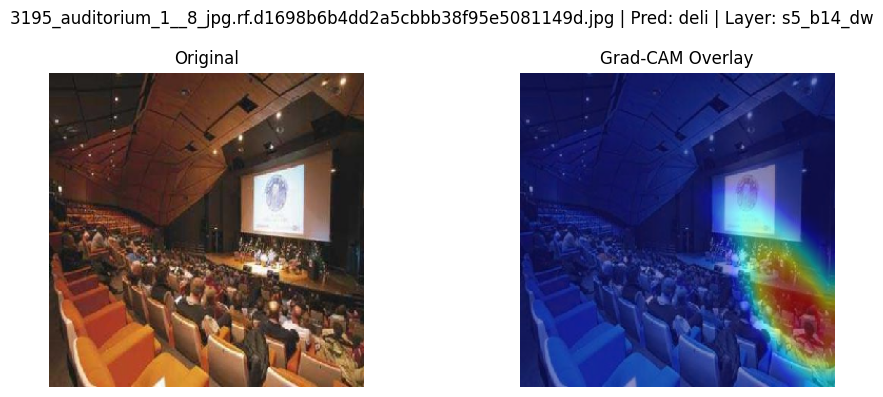

In [38]:
# Visualize Grad-CAM overlays for the first few test images using the scratch model
vis_cnt = 5

for img_i in range(min(vis_cnt, len(tst_data_loader.filepaths))):
    img_fp = tst_data_loader.filepaths[img_i]

    # Load image and prepare display and model inputs
    orig_pil, disp_arr, mdl_arr = prep_img_for_cam(img_fp)

    # Generate Grad-CAM heatmap and predicted class index
    cam_map, pred_i, cam_lyr = gen_gradcam_map(
        mdl_arr,
        best_scratch_mdl,
        conv_name=None
    )

    # Map predicted index to class name
    pred_nm = scene_cls_names[pred_i]

    # Overlay Grad-CAM heatmap on the image
    cam_ovl = blend_cam_on_img(disp_arr, cam_map, alpha=0.45)

    # Create visualization figure
    plt.figure(figsize=(10, 4))
    plt.suptitle(
        f"{os.path.basename(img_fp)} | Pred: {pred_nm} | Layer: {cam_lyr}",
        fontsize=12
    )

    # Show original image
    plt.subplot(1, 2, 1)
    plt.imshow(orig_pil)
    plt.title("Original")
    plt.axis("off")

    # Show Grad-CAM overlay
    plt.subplot(1, 2, 2)
    plt.imshow(cam_ovl)
    plt.title("Grad-CAM Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
